### Выгружаем данные и приводим к бинарной классификации

In [48]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader


tensors = torch.load('dataset/data_tensors.pt')
labels = (tensors['labels'] == 0).long()

In [49]:
class VkDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels
        

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]
    
groups = ['not cu', 'central_university']
data = VkDataset(tensors['images'], labels)

### проверяем что все верно

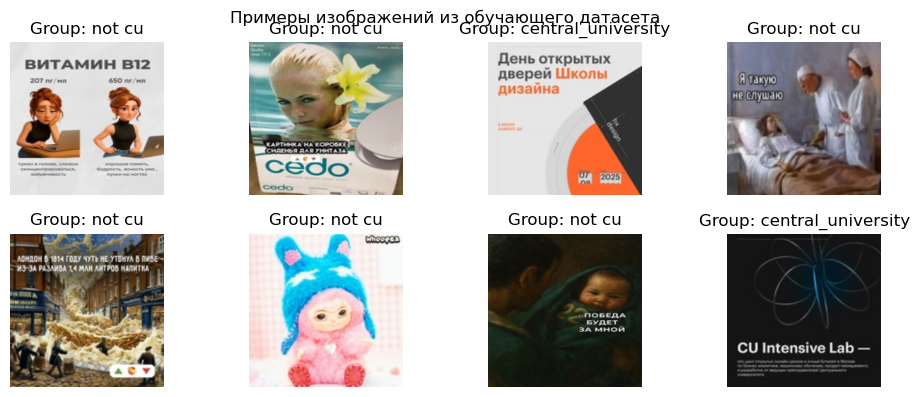

In [50]:
import matplotlib.pyplot as plt

plt.subplots(2, 4, figsize=(10, 4))
plt.suptitle("Примеры изображений из обучающего датасета")
j = 0
for i in np.random.randint(0, len(data), 8):
    plt.subplot(2, 4, j + 1)
    j += 1
    img = data[i][0]
    label = data[i][1].item()
    plt.imshow(img.permute(1, 2, 0).numpy())  # Преобразуем тензор в формат [H, W, C]
    plt.title(f"Group: {groups[label]}")
    plt.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

### Делим на train val test, и подаем в DataLoader

In [51]:
from torch.utils.data import random_split

torch.manual_seed(42)

train_ds, val_ds, test_ds = random_split(data, [0.6, 0.2, 0.2])

In [52]:
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=32, shuffle=False)

### Грузим модельку

In [88]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import torch
from tqdm import tqdm

assert torch.backends.mps.is_available()

# device = torch.device('mps')
device = torch.device('cpu')

model = models.resnet18()
model.fc = nn.Linear(512, 2)
# model.add_module('softmax', nn.Softmax(dim=1))
model = model.to(device)


### Преобразуем метки чтобы все работало

In [90]:
from sklearn.metrics import f1_score
from tqdm import tqdm

optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()
n_epochs = 10

for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    total_f1 = 0

    train_iterator = tqdm(train_dl, desc=f"Epoch {epoch+1} [Train]", leave=False)
    for image, label in train_iterator:
        image, label = image.to(device), label.to(device)
        logits = model(image)
        loss = criterion(logits, label)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    model.eval()
    val_loss = 0
    total_f1 = 0
    val_iterator = tqdm(val_dl, desc=f"Epoch {epoch+1} [Val]", leave=False)

    with torch.no_grad():
        for image, label in val_iterator:
            image, label = image.to(device), label.to(device)
            logits = model(image)

            loss = criterion(logits, label)
            preds = logits.softmax(dim=1).argmax(dim=1)
            total_f1 += f1_score(label.cpu(), preds.cpu(), average='macro')
            val_loss += loss.item()
    
    total_f1 /= len(val_dl)
    val_loss /= len(val_dl)
    total_loss /= len(train_dl)

    print(f'Epoch {epoch+1}: Train Loss = {total_loss:.3e}, Val Loss = {val_loss:.3e}, F1 = {total_f1:.3f}')


KeyboardInterrupt: 

In [60]:
model.eval()
test_loss = 0
with torch.no_grad():
    for image, label in test_dl:
        logits = model(image)
        loss = criterion(logits, label)
        test_loss += loss.item()
print(f'Test Loss = {test_loss:.3e}')



Test Loss = 4.013e+00


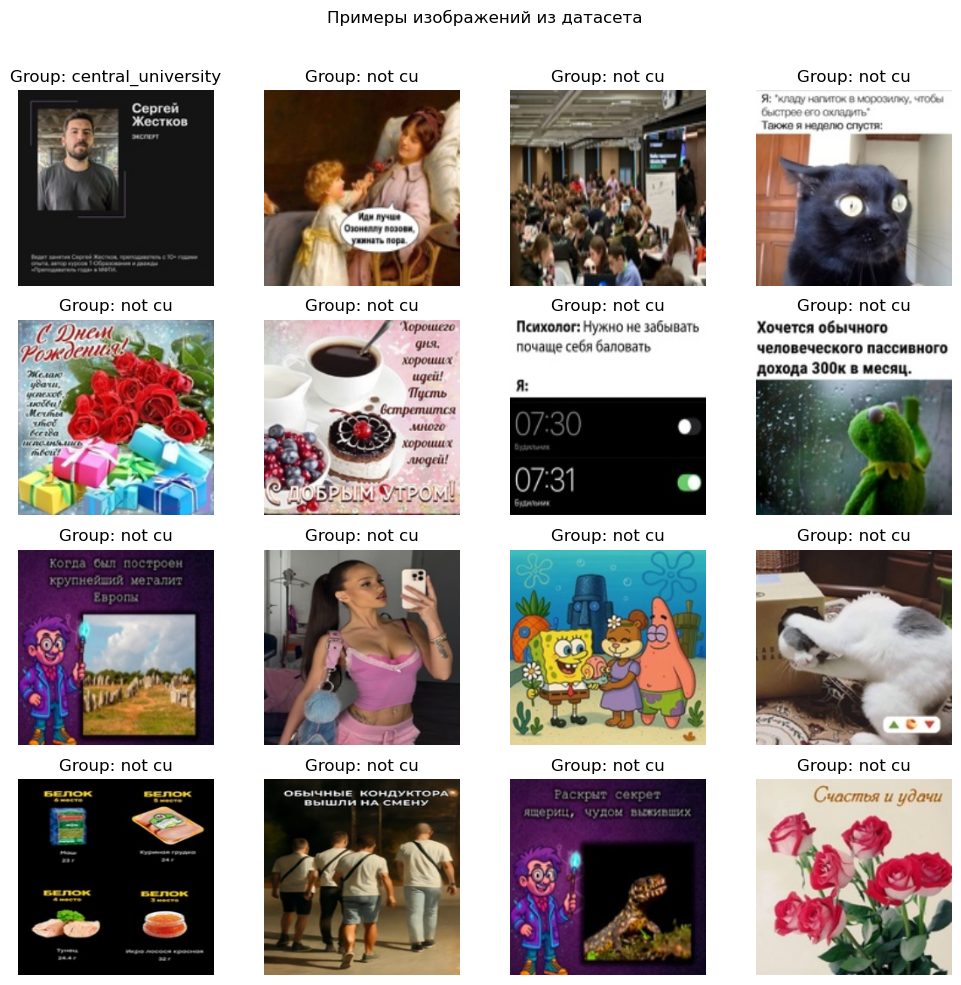

In [69]:
import matplotlib.pyplot as plt

plt.subplots(4, 4, figsize=(10, 10))
plt.suptitle("Примеры изображений из датасета")
j = 0
for i in np.random.randint(0, len(data), 16):
    plt.subplot(4, 4, j + 1)
    j += 1
    img = data[i][0]
    label = model(data[i][0].unsqueeze(0)).softmax(dim=1).argmax(dim=1)
    plt.imshow(img.permute(1, 2, 0).numpy())  # Преобразуем тензор в формат [H, W, C]
    plt.title(f"Group: {groups[label]}")
    plt.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()